In [6]:
!pip install --quiet pandas numpy matplotlib seaborn scikit-learn nltk
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

import nltk
import os
# Ensure a local nltk_data directory exists and is used
local_nltk_dir = os.path.join(os.getcwd(), 'nltk_data')
if not os.path.exists(local_nltk_dir):
    os.makedirs(local_nltk_dir, exist_ok=True)
# Prepend our local dir so downloads land there
nltk.data.path.insert(0, local_nltk_dir)

# Download required NLTK resources if not already present
for pkg in ['stopwords', 'wordnet']:
    try:
        nltk.data.find(f'corpora/{pkg}')
    except LookupError:
        try:
            nltk.download(pkg, download_dir=local_nltk_dir)
        except Exception:
            pass

from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

[nltk_data] Downloading package wordnet to c:\Users\a00548169\OneDrive
[nltk_data]     - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\
[nltk_data]     data\2014-2025\USD\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [7]:
df = pd.read_csv("US_research.csv", encoding="utf-8")
# Drop 'Unnamed: 0' column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns="Unnamed: 0")

# Continue with date parsing and cleanup
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')

# Drop rows with missing critical values (Date or ETF)
df = df.dropna(subset=[c for c in ['Date', 'ETF'] if c in df.columns]).reset_index(drop=True)

df

,Index,Date,Headline,gold,oil,bond,cad,cny,eur,jpy,mxn,vix,bitcoin,ETF
0,1,2014-01-02,Russell Banks: By the Book,1225.2,95.44,2.991,1.0668,6.0507,0.7314,104.76,13.1500,14.23,856.9,86.86
1,2,2014-01-03,Annual Sales for American Automakers Reach a 6...,1238.6,93.96,2.998,1.0632,6.0515,0.7359,104.82,13.0970,13.76,884.3,86.24
2,3,2014-01-04,"Help the Working Poor, but Share the Burden",1238.6,93.96,2.998,1.0632,6.0515,0.7359,104.82,13.0970,13.76,924.7,86.24
3,4,2014-01-05,Democrats Press Revival of Jobless Aid That Ex...,1238.6,93.96,2.998,1.0632,6.0515,0.7359,104.82,13.0970,13.76,1014.7,86.24
4,5,2014-01-06,"Growth Returns to Tech, but Profits Will Not B...",1238.0,93.43,2.958,1.0653,6.0527,0.7338,104.21,13.0760,13.55,1012.7,85.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4377,4378,2025-12-27,I Broke the Lease on an Illegal Rental. Can I ...,4552.7,56.74,4.134,1.3672,7.0067,0.8494,156.57,17.9115,13.60,87850.8,623.89
4378,4379,2025-12-28,Trump and Zelensky Meet to Iron Out Peace Plan...,4552.7,56.74,4.134,1.3672,7.0067,0.8494,156.57,17.9115,13.60,87904.3,623.89
4379,4380,2025-12-29,"Zelensky and Netanyahu Go to Mar-a-Lago, and S...",4327.0,58.08,4.116,1.3691,7.0060,0.8495,156.06,17.9740,14.20,87217.7,620.87
4380,4381,2025-12-30,Protests Over Sinking Economy in Iran Spread t...,4386.3,57.95,4.128,1.3697,6.9964,0.8513,156.41,17.9905,14.33,88469.6,619.43


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Get numeric columns to scale (excluding Date if present)
columns_to_scale = [col for col in ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'VIX'] if col in df.columns]

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
df

,Index,Date,Headline,gold,oil,bond,cad,cny,eur,jpy,mxn,vix,bitcoin,ETF
0,1,2014-01-02,Russell Banks: By the Book,-0.771498,1.655113,0.329000,-3.034021,-1.935936,-2.687012,-0.964533,-2.392156,14.23,-0.780258,86.86
1,2,2014-01-03,Annual Sales for American Automakers Reach a 6...,-0.751103,1.575438,0.335443,-3.080177,-1.933702,-2.607330,-0.961059,-2.415747,13.76,-0.779383,86.24
2,3,2014-01-04,"Help the Working Poor, but Share the Burden",-0.751103,1.575438,0.335443,-3.080177,-1.933702,-2.607330,-0.961059,-2.415747,13.76,-0.778093,86.24
3,4,2014-01-05,Democrats Press Revival of Jobless Aid That Ex...,-0.751103,1.575438,0.335443,-3.080177,-1.933702,-2.607330,-0.961059,-2.415747,13.76,-0.775219,86.24
4,5,2014-01-06,"Growth Returns to Tech, but Profits Will Not B...",-0.752016,1.546905,0.298624,-3.053253,-1.930350,-2.644515,-0.996387,-2.425094,13.55,-0.775282,85.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4377,4378,2025-12-27,I Broke the Lease on an Illegal Rental. Can I ...,4.293144,-0.428286,1.381122,0.817368,0.734529,-0.597585,2.036028,-0.272824,13.60,1.997649,623.89
4378,4379,2025-12-28,Trump and Zelensky Meet to Iron Out Peace Plan...,4.293144,-0.428286,1.381122,0.817368,0.734529,-0.597585,2.036028,-0.272824,13.60,1.999358,623.89
4379,4380,2025-12-29,"Zelensky and Netanyahu Go to Mar-a-Lago, and S...",3.949616,-0.356148,1.364553,0.841727,0.732573,-0.595814,2.006491,-0.245005,14.20,1.977433,620.87
4380,4381,2025-12-30,Protests Over Sinking Economy in Iran Spread t...,4.039874,-0.363146,1.375599,0.849420,0.705757,-0.563942,2.026761,-0.237661,14.33,2.017409,619.43


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4382 entries, 0 to 4381
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Index     4382 non-null   int64         
 1   Date      4382 non-null   datetime64[us]
 2   Headline  4382 non-null   str           
 3   gold      4382 non-null   float64       
 4   oil       4382 non-null   float64       
 5   bond      4382 non-null   float64       
 6   cad       4382 non-null   float64       
 7   cny       4382 non-null   float64       
 8   eur       4382 non-null   float64       
 9   jpy       4382 non-null   float64       
 10  mxn       4382 non-null   float64       
 11  vix       4382 non-null   float64       
 12  bitcoin   4382 non-null   float64       
 13  ETF       4382 non-null   float64       
dtypes: datetime64[us](1), float64(11), int64(1), str(1)
memory usage: 479.4 KB


In [10]:
df.describe()

,Index,Date,gold,oil,bond,cad,cny,eur,jpy,mxn,vix,bitcoin,ETF
count,4382.000000,4382,4.382000e+03,4.382000e+03,4.382000e+03,4.382000e+03,4.382000e+03,4.382000e+03,4.382000e+03,4.382000e+03,4382.000000,4.382000e+03,4382.000000
mean,2191.500000,2020-01-01 12:00:00,3.113286e-16,3.113286e-16,1.816084e-16,2.075524e-16,-5.188810e-16,-1.816084e-16,-3.113286e-16,-7.783216e-16,17.904856,-1.556643e-16,256.848295
min,1.000000,2014-01-02 00:00:00,-1.038771e+00,-2.859995e+00,-1.952898e+00,-3.081459e+00,-1.962473e+00,-2.929598e+00,-1.247736e+00,-2.531249e+00,9.140000,-8.040566e-01,83.900000
25%,1096.250000,2017-01-01 06:00:00,-7.085994e-01,-7.593691e-01,-7.442928e-01,-4.374750e-01,-8.498028e-01,-5.515469e-01,-7.398244e-01,-4.380665e-01,13.310000,-7.778027e-01,120.400000
50%,2191.500000,2020-01-01 12:00:00,-3.113047e-01,-8.966656e-02,-1.818727e-01,1.788883e-01,7.627038e-02,1.399116e-01,-4.739958e-01,1.671551e-01,16.120000,-4.984942e-01,203.110000
75%,3286.750000,2022-12-31 18:00:00,2.916199e-01,6.218924e-01,8.633452e-01,6.494141e-01,9.222436e-01,6.556281e-01,8.762857e-01,6.424081e-01,20.747500,4.615323e-01,359.990000
max,4382.000000,2025-12-31 00:00:00,4.293144e+00,2.965447e+00,2.169062e+00,1.976374e+00,1.693494e+00,2.818096e+00,2.331972e+00,3.032694e+00,82.690000,3.175127e+00,635.770000
std,1265.118769,NaN,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,6.888300,1.000114e+00,145.248501


In [11]:
# Ensure stopwords are available, with fallback to downloading if necessary
try:
    stopwords_object = stopwords.words('english')
except LookupError:
    import nltk
    nltk.download('stopwords')
    stopwords_object = stopwords.words('english')

# Use RegexpTokenizer to avoid punkt dependency
tokenizer = RegexpTokenizer(r"[a-zA-Z]+")

# Preprocessing
if 'Headline' in df.columns:
    df["Headline"] = df["Headline"].astype(str).str.lower()


def preprocessing_text(data):
    if pd.isna(data):
        return ''

    text = re.sub("[^a-zA-Z]"," ", str(data))

    tokens = tokenizer.tokenize(text)

    word_tokens = [w for w in tokens if w not in stopwords_object]

    stemmer = PorterStemmer()
    stem_words = [stemmer.stem(w) for w in word_tokens]

    lemmer = WordNetLemmatizer()
    lem_words = [lemmer.lemmatize(w) for w in stem_words]

    return " ".join(lem_words)

# Apply preprocessing and create Headline2
if 'Headline' in df.columns:
    df["Headline2"] = df["Headline"].apply(preprocessing_text)
    df
else:
    print('No Headline column found')

# If another cell applies preprocessing again, guard it with try/except to avoid duplicate errors
try:
    if 'Headline2' not in df.columns and 'Headline' in df.columns:
        df["Headline2"] = df["Headline"].apply(preprocessing_text)
except Exception as e:
    print('Preprocessing skipped due to:', e)

df

,Index,Date,Headline,gold,oil,bond,cad,cny,eur,jpy,mxn,vix,bitcoin,ETF,Headline2
0,1,2014-01-02,russell banks: by the book,-0.771498,1.655113,0.329000,-3.034021,-1.935936,-2.687012,-0.964533,-2.392156,14.23,-0.780258,86.86,russel bank book
1,2,2014-01-03,annual sales for american automakers reach a 6...,-0.751103,1.575438,0.335443,-3.080177,-1.933702,-2.607330,-0.961059,-2.415747,13.76,-0.779383,86.24,annual sale american automak reach year high
2,3,2014-01-04,"help the working poor, but share the burden",-0.751103,1.575438,0.335443,-3.080177,-1.933702,-2.607330,-0.961059,-2.415747,13.76,-0.778093,86.24,help work poor share burden
3,4,2014-01-05,democrats press revival of jobless aid that ex...,-0.751103,1.575438,0.335443,-3.080177,-1.933702,-2.607330,-0.961059,-2.415747,13.76,-0.775219,86.24,democrat press reviv jobless aid expir
4,5,2014-01-06,"growth returns to tech, but profits will not b...",-0.752016,1.546905,0.298624,-3.053253,-1.930350,-2.644515,-0.996387,-2.425094,13.55,-0.775282,85.92,growth return tech profit easi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4377,4378,2025-12-27,i broke the lease on an illegal rental. can i ...,4.293144,-0.428286,1.381122,0.817368,0.734529,-0.597585,2.036028,-0.272824,13.60,1.997649,623.89,broke lea illeg rental get secur deposit back
4378,4379,2025-12-28,trump and zelensky meet to iron out peace plan...,4.293144,-0.428286,1.381122,0.817368,0.734529,-0.597585,2.036028,-0.272824,13.60,1.999358,623.89,trump zelenski meet iron peac plan deal remain...
4379,4380,2025-12-29,"zelensky and netanyahu go to mar-a-lago, and s...",3.949616,-0.356148,1.364553,0.841727,0.732573,-0.595814,2.006491,-0.245005,14.20,1.977433,620.87,zelenski netanyahu go mar lago student loan bo...
4380,4381,2025-12-30,protests over sinking economy in iran spread t...,4.039874,-0.363146,1.375599,0.849420,0.705757,-0.563942,2.026761,-0.237661,14.33,2.017409,619.43,protest sink economi iran spread univers


In [12]:
df["Headline2"] = df["Headline"].apply(preprocessing_text)
df

,Index,Date,Headline,gold,oil,bond,cad,cny,eur,jpy,mxn,vix,bitcoin,ETF,Headline2
0,1,2014-01-02,russell banks: by the book,-0.771498,1.655113,0.329000,-3.034021,-1.935936,-2.687012,-0.964533,-2.392156,14.23,-0.780258,86.86,russel bank book
1,2,2014-01-03,annual sales for american automakers reach a 6...,-0.751103,1.575438,0.335443,-3.080177,-1.933702,-2.607330,-0.961059,-2.415747,13.76,-0.779383,86.24,annual sale american automak reach year high
2,3,2014-01-04,"help the working poor, but share the burden",-0.751103,1.575438,0.335443,-3.080177,-1.933702,-2.607330,-0.961059,-2.415747,13.76,-0.778093,86.24,help work poor share burden
3,4,2014-01-05,democrats press revival of jobless aid that ex...,-0.751103,1.575438,0.335443,-3.080177,-1.933702,-2.607330,-0.961059,-2.415747,13.76,-0.775219,86.24,democrat press reviv jobless aid expir
4,5,2014-01-06,"growth returns to tech, but profits will not b...",-0.752016,1.546905,0.298624,-3.053253,-1.930350,-2.644515,-0.996387,-2.425094,13.55,-0.775282,85.92,growth return tech profit easi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4377,4378,2025-12-27,i broke the lease on an illegal rental. can i ...,4.293144,-0.428286,1.381122,0.817368,0.734529,-0.597585,2.036028,-0.272824,13.60,1.997649,623.89,broke lea illeg rental get secur deposit back
4378,4379,2025-12-28,trump and zelensky meet to iron out peace plan...,4.293144,-0.428286,1.381122,0.817368,0.734529,-0.597585,2.036028,-0.272824,13.60,1.999358,623.89,trump zelenski meet iron peac plan deal remain...
4379,4380,2025-12-29,"zelensky and netanyahu go to mar-a-lago, and s...",3.949616,-0.356148,1.364553,0.841727,0.732573,-0.595814,2.006491,-0.245005,14.20,1.977433,620.87,zelenski netanyahu go mar lago student loan bo...
4380,4381,2025-12-30,protests over sinking economy in iran spread t...,4.039874,-0.363146,1.375599,0.849420,0.705757,-0.563942,2.026761,-0.237661,14.33,2.017409,619.43,protest sink economi iran spread univers


## **TF-IDF**

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [14]:
tfidf_result = tfidf.fit_transform(df["Headline2"])
df["tfidf_Headline"] = list(tfidf_result.toarray())

In [15]:
df["tfidf_Headline"] = np.array(df['tfidf_Headline'].tolist())
X = df[['tfidf_Headline', 'gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn','vix','bitcoin']]
y = df["ETF"].values

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42)

### **TF-IDF + Random Forest**

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

rf = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_split=2, random_state=42)
rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print(f"Random Forest RMSE: {rf_rmse}")

rf_mae = mean_absolute_error(y_test, rf_predictions)
print(f"Random Forest MAE: {rf_mae}")

rf_mape = mean_absolute_percentage_error(y_test, rf_predictions)
print(f"Random Forest MAPE: {rf_mape}")

r2 = r2_score(y_test, rf_predictions)
print(f'Random Forest R제곱: {r2}')

Random Forest RMSE: 3.4310205224591557
Random Forest MAE: 1.7497087463974565
Random Forest MAPE: 0.006697971840389619
Random Forest R제곱: 0.9994445327055284


In [17]:
feature_importances = rf.feature_importances_

for feature, importance in zip(X_train.columns, feature_importances):
    print(f"{feature}: {importance}")

tfidf_Headline: 6.470037850081207e-10
gold: 0.18227239214590815
oil: 0.0020592427147299404
bond: 0.0006097241919646302
cad: 0.000792689968866003
cny: 0.004127250599949415
eur: 0.01843056350011999
jpy: 0.0006753304626428982
mxn: 0.0016800045756279439
vix: 0.007487510922559317
bitcoin: 0.7818652902706279


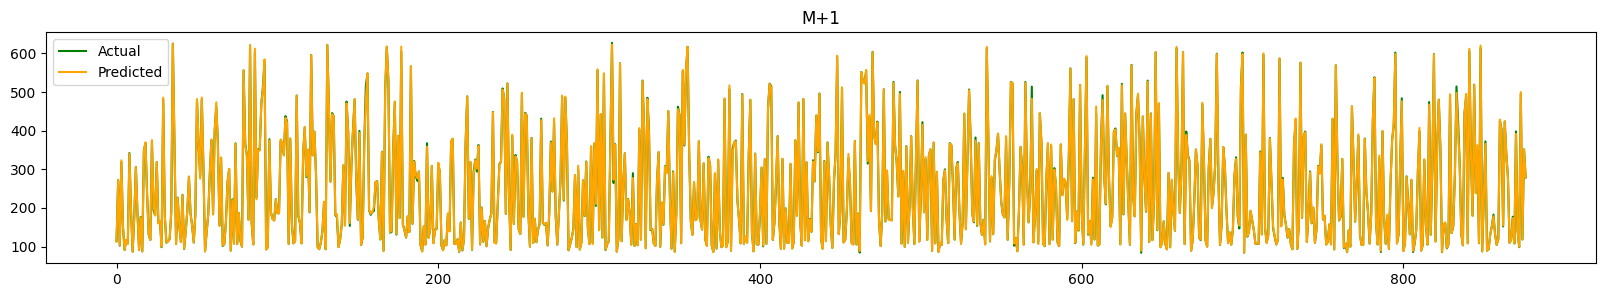

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 3))
plt.plot(y_test, label='Actual', color='green')
plt.plot(rf_predictions, label='Predicted', color='orange', linestyle='-')
plt.title('M+1')
plt.legend()
plt.show()

### **TF-IDF + LightGBM**

In [19]:
!pip install lightgbm

In [20]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# TF-IDF 데이터 사용 (이미 준비된 X_train, X_test, y_train, y_test 사용)
# LightGBM 모델 생성
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=20,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

# 모델 학습
lgb_model.fit(X_train, y_train)

# 예측
lgb_predictions = lgb_model.predict(X_test)

# 평가
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_predictions))
print(f"TF-IDF + LightGBM RMSE: {lgb_rmse:.4f}")

lgb_mae = mean_absolute_error(y_test, lgb_predictions)
print(f"TF-IDF + LightGBM MAE: {lgb_mae:.4f}")

lgb_mape = mean_absolute_percentage_error(y_test, lgb_predictions)
print(f"TF-IDF + LightGBM MAPE: {lgb_mape:.4f} ({lgb_mape*100:.2f}%)")

lgb_r2 = r2_score(y_test, lgb_predictions)
print(f'TF-IDF + LightGBM R²: {lgb_r2:.4f} ({lgb_r2*100:.2f}%)')

TF-IDF + LightGBM RMSE: 4.0587
TF-IDF + LightGBM MAE: 2.6399
TF-IDF + LightGBM MAPE: 0.0112 (1.12%)
TF-IDF + LightGBM R²: 0.9992 (99.92%)


In [21]:
# LightGBM 특성 중요도
lgb_feature_importances = lgb_model.feature_importances_

print("\n=== LightGBM Feature Importances ===")
feature_names = ['tfidf_Headline', 'gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn','vix','bitcoin']
for feature, importance in zip(feature_names, lgb_feature_importances):
    print(f"{feature}: {importance:.2f}")


=== LightGBM Feature Importances ===
tfidf_Headline: 0.00
gold: 386.00
oil: 241.00
bond: 231.00
cad: 243.00
cny: 301.00
eur: 266.00
jpy: 257.00
mxn: 263.00
vix: 484.00
bitcoin: 328.00


### **TF-IDF + BILSTM**

In [23]:
!pip install --quiet tensorflow keras

from tensorflow import keras
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Bidirectional
from keras.layers import PReLU

# 컬럼명 확인 및 수정 (vix vs VIX)
if 'VIX' in df.columns and 'vix' not in df.columns:
    vix_col = 'VIX'
elif 'vix' in df.columns:
    vix_col = 'vix'
else:
    print("Warning: VIX column not found")
    vix_col = None

# X 데이터 준비 (vix 컬럼 처리)
feature_cols = ['tfidf_Headline', 'gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin']
if vix_col:
    feature_cols.insert(-1, vix_col)  # bitcoin 앞에 추가

X = df[feature_cols]
y = df["ETF"].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# numpy array로 변환 (DataFrame의 values 사용)
X_lstm_train = np.reshape(X_train.values, (X_train.shape[0], X_train.shape[1], 1))
y_lstm_train = np.reshape(y_train, (y_train.shape[0], 1))

X_lstm_val = np.reshape(X_val.values, (X_val.shape[0], X_val.shape[1], 1))
y_lstm_val = np.reshape(y_val, (y_val.shape[0], 1))

X_lstm_test = np.reshape(X_test.values, (X_test.shape[0], X_test.shape[1], 1))
y_lstm_test = np.reshape(y_test, (y_test.shape[0], 1))

lstm_model = Sequential()
lstm_model.add(Bidirectional(LSTM(392, return_sequences=False), input_shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])))
lstm_model.add(Dense(256))
lstm_model.add(PReLU())
lstm_model.add(Dense(64))
lstm_model.add(PReLU())
lstm_model.add(Dense(1, activation='linear'))
lstm_model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mape'])

print("모델이 성공적으로 생성되었습니다!")
print(f"입력 shape: {X_lstm_train.shape}")

c:\Users\a00548169\OneDrive - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\data\2014-2025\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


모델이 성공적으로 생성되었습니다!
입력 shape: (3505, 11, 1)


In [26]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 784)            │     1,235,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu (PReLU)                 │ (None, 256)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_1 (PReLU)               │ (None, 64)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,360,133 (16.63 MB)

 Trainable params: 1,453,377 (5.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,906,756 (11.09 MB)

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

history = lstm_model.fit(X_lstm_train, y_lstm_train, epochs=300, batch_size=32,
                         validation_data=(X_lstm_val, y_lstm_val),verbose=1)

lstm_predictions = lstm_model.predict(X_lstm_test)

lstm_rmse = np.sqrt(mean_squared_error(y_lstm_test, lstm_predictions))
print(f"TF-IDF + BILSTM RMSE: {lstm_rmse}")

lstm_mae = mean_absolute_error(y_lstm_test, lstm_predictions)
print(f"TF-IDF + BILSTM MAE: {lstm_mae}")

lstm_mape = mean_absolute_percentage_error(y_lstm_test, lstm_predictions)
print(f"TF-IDF + BILSTM MAPE: {lstm_mape}")

r2 = r2_score(y_lstm_test, lstm_predictions)
print(f'TF-IDF + BILSTM R제곱: {r2}')

Epoch 1/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 17.5591 - mape: 1.2693 - val_loss: 11.0971 - val_mape: 0.8983
Epoch 2/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 8.9498 - mape: 0.9068 - val_loss: 9.8534 - val_mape: 0.8558
Epoch 3/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 7.0862 - mape: 0.7772 - val_loss: 9.3677 - val_mape: 0.8130
Epoch 4/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 8.5459 - mape: 0.8927 - val_loss: 11.2873 - val_mape: 0.9008
Epoch 5/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 13.1606 - mape: 1.1331 - val_loss: 15.0159 - val_mape: 1.1487
Epoch 6/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 9.6017 - mape: 0.9086 - val_loss: 12.3520 - val_mape: 1.0251
Epoch 7/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 10.3037 - mape: 0.9745 - val_loss: 11.7539 - val_mape: 1.0515
Epoch 8/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 7.3714 - mape: 0.7922 - val_loss: 21.3046 - val_mape: 1.5551
Epoch 9/300
110

## **Hybrid (TF-IDF + RF + BiLSTM)**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# Step 1: Random Forest로 피처 중요도 추출
# 가능한 모든 수치 특성 후보
candidate_features = ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'VIX']
# 실제 존재하는 특성만 선택
available_features = [col for col in candidate_features if col in df.columns]
print(f"Available features: {available_features}")

X_all = df[available_features]
y = df["ETF"].values

# RF 학습
rf_hybrid = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_split=2, random_state=42)
rf_hybrid.fit(X_all, y)

# 피처 중요도 추출
importances = pd.Series(rf_hybrid.feature_importances_, index=X_all.columns)
print("\nFeature Importances:")
print(importances.sort_values(ascending=False))

# 상위 5개 피처 선택
top5_features = importances.sort_values(ascending=False).head(5).index.tolist()
print(f"\nTop 5 Features: {top5_features}")

# Step 2: 상위 5개 피처로 BiLSTM 학습
X_top5 = df[top5_features]
y = df["ETF"].values

X_train, X_temp, y_train, y_temp = train_test_split(X_top5, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_lstm_train = np.reshape(X_train.values, (X_train.shape[0], X_train.shape[1], 1))
y_lstm_train = np.reshape(y_train, (y_train.shape[0], 1))

X_lstm_val = np.reshape(X_val.values, (X_val.shape[0], X_val.shape[1], 1))
y_lstm_val = np.reshape(y_val, (y_val.shape[0], 1))

X_lstm_test = np.reshape(X_test.values, (X_test.shape[0], X_test.shape[1], 1))
y_lstm_test = np.reshape(y_test, (y_test.shape[0], 1))

# BiLSTM 모델 생성
hybrid_model = Sequential()
hybrid_model.add(Bidirectional(LSTM(128, return_sequences=False), input_shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])))
hybrid_model.add(Dense(128))
hybrid_model.add(PReLU())
hybrid_model.add(Dense(64))
hybrid_model.add(PReLU())
hybrid_model.add(Dense(1, activation='linear'))
hybrid_model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mape'])

print("\n=== Hybrid BiLSTM Model (Top 5 Features) ===")
hybrid_model.summary()

# 학습
history = hybrid_model.fit(X_lstm_train, y_lstm_train, epochs=300, batch_size=32,
                         validation_data=(X_lstm_val, y_lstm_val), verbose=1)

# 예측 및 평가
hybrid_predictions = hybrid_model.predict(X_lstm_test)

hybrid_rmse = np.sqrt(mean_squared_error(y_lstm_test, hybrid_predictions))
print(f"\nHybrid RMSE: {hybrid_rmse}")

hybrid_mae = mean_absolute_error(y_lstm_test, hybrid_predictions)
print(f"Hybrid MAE: {hybrid_mae}")

hybrid_mape = mean_absolute_percentage_error(y_lstm_test, hybrid_predictions)
print(f"Hybrid MAPE: {hybrid_mape}")

r2 = r2_score(y_lstm_test, hybrid_predictions)
print(f'Hybrid R제곱: {r2}')


Available features: ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin']

Feature Importances:
bitcoin    0.787267
gold       0.178869
eur        0.018433
mxn        0.005403
cny        0.004521
oil        0.002682
jpy        0.001165
cad        0.000949
bond       0.000713
dtype: float64

Top 5 Features: ['bitcoin', 'gold', 'eur', 'mxn', 'cny']

=== Hybrid BiLSTM Model (Top 5 Features) ===


c:\Users\a00548169\OneDrive - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\data\2014-2025\USD\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_11                │ (None, 256)            │       133,120 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_22 (PReLU)              │ (None, 128)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_23 (PReLU)              │ (None, 64)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,529 (681.75 KB)

 Trainable params: 174,529 (681.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 36719.0898 - mape: 53.3359 - val_loss: 3156.4233 - val_mape: 17.8787
Epoch 2/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2020.9127 - mape: 15.9112 - val_loss: 1468.3134 - val_mape: 14.0161
Epoch 3/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1289.8119 - mape: 13.3120 - val_loss: 1206.7897 - val_mape: 13.1340
Epoch 4/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1025.6505 - mape: 12.1718 - val_loss: 910.1046 - val_mape: 11.9812
Epoch 5/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 863.1740 - mape: 11.1848 - val_loss: 799.5637 - val_mape: 10.8192
Epoch 6/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 805.0483 - mape: 10.6579 - val_loss: 842.6381 - val_mape: 10.5682
Epoch 7/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 702.8849 - mape: 9.9639 - val_loss: 708.6807 - val_mape: 9.4676
Epoch 8/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 671.9103 - mape: 9.5173 - val_loss: 693.7213

## **TF-IDF + LightGBM**

In [ ]:
!pip install --quiet lightgbm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import lightgbm as lgb
import numpy as np

# TF-IDF 벡터화
# 전처리된 헤드라인 사용 (preprocessing_text 함수로 처리된 데이터)
if 'cleaned_headline' in df.columns:
    headline_col = 'cleaned_headline'
else:
    headline_col = 'Headline'

tfidf_vectorizer = TfidfVectorizer(max_features=500, min_df=2, max_df=0.8)
tfidf_features = tfidf_vectorizer.fit_transform(df[headline_col].fillna('')).toarray()
print(f"TF-IDF 특성 shape: {tfidf_features.shape}")

# 금융 지표 특성
financial_features = ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'VIX']
financial_features = [c for c in financial_features if c in df.columns]
financial_data = df[financial_features].values
print(f"금융 지표 shape: {financial_data.shape}")

# TF-IDF + 금융 지표 결합
X = np.hstack([tfidf_features, financial_data])
y = df["ETF"].values
print(f"최종 특성 shape: {X.shape}")

# 훈련/테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

# LightGBM 모델 훈련
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'verbose': -1,
    'random_state': 20
}

lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train)

print("\nLightGBM 모델 훈련 중...")
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=200,
    valid_sets=[lgb_train, lgb_eval],
    valid_names=['train', 'test']
)

# 예측 및 평가
lgb_predictions = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_predictions))
print(f"\nTF-IDF + LightGBM RMSE: {lgb_rmse:.4f}")

lgb_mae = mean_absolute_error(y_test, lgb_predictions)
print(f"TF-IDF + LightGBM MAE: {lgb_mae:.4f}")

lgb_mape = mean_absolute_percentage_error(y_test, lgb_predictions)
print(f"TF-IDF + LightGBM MAPE: {lgb_mape:.4f}")

lgb_r2 = r2_score(y_test, lgb_predictions)
print(f'TF-IDF + LightGBM R제곱: {lgb_r2:.4f}')

# 특성 중요도 확인
print("\n상위 10개 중요 특성:")
feature_importance = lgb_model.feature_importance(importance_type='gain')
feature_names = [f'tfidf_{i}' for i in range(tfidf_features.shape[1])] + financial_features
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)
print(importance_df.head(10))

TF-IDF 특성 shape: (4382, 500)
금융 지표 shape: (4382, 9)
최종 특성 shape: (4382, 509)

LightGBM 모델 훈련 중...

TF-IDF + LightGBM RMSE: 4.3925
TF-IDF + LightGBM MAE: 3.0524
TF-IDF + LightGBM MAPE: 0.0130
TF-IDF + LightGBM R제곱: 0.9991

상위 10개 중요 특성:
      feature    importance
508   bitcoin  5.639354e+08
500      gold  1.618935e+08
505       eur  1.288833e+07
507       mxn  5.527651e+06
504       cny  5.038278e+06
501       oil  3.458929e+06
506       jpy  1.271862e+06
502      bond  1.227464e+06
503       cad  5.657757e+05
24   tfidf_24  1.792544e+04


## **FinBERT**

In [31]:
!pip install pandas transformers torch

  Using cached transformers-5.0.0-py3-none-any.whl.metadata (37 kB)
  Using cached torch-2.10.0-cp312-cp312-win_amd64.whl.metadata (31 kB)
  Using cached filelock-3.20.3-py3-none-any.whl.metadata (2.1 kB)
  Using cached huggingface_hub-1.3.4-py3-none-any.whl.metadata (13 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer_slim-0.21.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached fsspec-2026.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-win_amd64.whl.metadata (5.0 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any

In [32]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('./finbert')
model = BertModel.from_pretrained('./finbert')

df['headline']=df["Headline"]

c:\Users\a00548169\OneDrive - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\data\2014-2025\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 783.68it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: ./finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [33]:
tokenized_headlines = df['headline'].apply((lambda x: tokenizer.encode(x, add_special_tokens=True)))

max_len = max(map(len, tokenized_headlines))
padded_headlines = torch.tensor([i + [0]*(max_len-len(i)) for i in tokenized_headlines])

In [34]:
attention_mask = (padded_headlines != 0).float()

In [35]:
with torch.no_grad():
    outputs = model(padded_headlines, attention_mask=attention_mask)

In [36]:
finbert_embeddings = outputs.last_hidden_state[:, 0, :]

In [37]:
finbert_embeddings.shape

torch.Size([4382, 768])

In [38]:
finbert_headline = finbert_embeddings.tolist()
df['finbert_headline'] = finbert_headline
df

,Index,Date,Headline,gold,oil,bond,cad,cny,eur,jpy,mxn,vix,bitcoin,ETF,Headline2,tfidf_Headline,headline,finbert_headline
0,1,2014-01-02,russell banks: by the book,-0.771498,1.655113,0.329000,-3.034021,-1.935936,-2.687012,-0.964533,-2.392156,14.23,-0.780258,86.86,russel bank book,0.0,russell banks: by the book,"[0.18540622293949127, 0.5637153387069702, -1.0..."
1,2,2014-01-03,annual sales for american automakers reach a 6...,-0.751103,1.575438,0.335443,-3.080177,-1.933702,-2.607330,-0.961059,-2.415747,13.76,-0.779383,86.24,annual sale american automak reach year high,0.0,annual sales for american automakers reach a 6...,"[0.6880272626876831, -0.1555805802345276, 0.81..."
2,3,2014-01-04,"help the working poor, but share the burden",-0.751103,1.575438,0.335443,-3.080177,-1.933702,-2.607330,-0.961059,-2.415747,13.76,-0.778093,86.24,help work poor share burden,0.0,"help the working poor, but share the burden","[0.12937678396701813, 1.0238862037658691, -1.2..."
3,4,2014-01-05,democrats press revival of jobless aid that ex...,-0.751103,1.575438,0.335443,-3.080177,-1.933702,-2.607330,-0.961059,-2.415747,13.76,-0.775219,86.24,democrat press reviv jobless aid expir,0.0,democrats press revival of jobless aid that ex...,"[0.595851719379425, -0.03873828053474426, 0.17..."
4,5,2014-01-06,"growth returns to tech, but profits will not b...",-0.752016,1.546905,0.298624,-3.053253,-1.930350,-2.644515,-0.996387,-2.425094,13.55,-0.775282,85.92,growth return tech profit easi,0.0,"growth returns to tech, but profits will not b...","[0.827682614326477, -0.3693569600582123, 0.033..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4377,4378,2025-12-27,i broke the lease on an illegal rental. can i ...,4.293144,-0.428286,1.381122,0.817368,0.734529,-0.597585,2.036028,-0.272824,13.60,1.997649,623.89,broke lea illeg rental get secur deposit back,0.0,i broke the lease on an illegal rental. can i ...,"[0.5102755427360535, 0.24161997437477112, 0.26..."
4378,4379,2025-12-28,trump and zelensky meet to iron out peace plan...,4.293144,-0.428286,1.381122,0.817368,0.734529,-0.597585,2.036028,-0.272824,13.60,1.999358,623.89,trump zelenski meet iron peac plan deal remain...,0.0,trump and zelensky meet to iron out peace plan...,"[-0.7160391211509705, -0.07265307009220123, 0...."
4379,4380,2025-12-29,"zelensky and netanyahu go to mar-a-lago, and s...",3.949616,-0.356148,1.364553,0.841727,0.732573,-0.595814,2.006491,-0.245005,14.20,1.977433,620.87,zelenski netanyahu go mar lago student loan bo...,0.0,"zelensky and netanyahu go to mar-a-lago, and s...","[0.29879850149154663, 0.26205500960350037, -0...."
4380,4381,2025-12-30,protests over sinking economy in iran spread t...,4.039874,-0.363146,1.375599,0.849420,0.705757,-0.563942,2.026761,-0.237661,14.33,2.017409,619.43,protest sink economi iran spread univers,0.0,protests over sinking economy in iran spread t...,"[-0.06478835642337799, -0.3178606927394867, 0...."


## **FINBERT + Ridge**

In [40]:
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# 데이터 전처리: FinBERT 임베딩을 numpy array로 변환
finbert_array = np.array([np.array(x) for x in df['finbert_headline']])
print(f"FinBERT 임베딩 shape: {finbert_array.shape}")

# 금융 지표 특성
financial_features = ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'VIX']
financial_features = [c for c in financial_features if c in df.columns]
financial_data = df[financial_features].values
print(f"금융 지표 shape: {financial_data.shape}")

# FinBERT 임베딩을 PCA로 차원 축소 (768 → 50)
pca = PCA(n_components=50, random_state=20)
finbert_reduced = pca.fit_transform(finbert_array)
print(f"PCA 후 FinBERT shape: {finbert_reduced.shape}")
print(f"PCA 설명 분산 비율: {pca.explained_variance_ratio_.sum():.4f}")

# FinBERT(PCA) + 금융 지표 결합
X = np.hstack([finbert_reduced, financial_data])
y = df["ETF"].values
print(f"최종 특성 shape: {X.shape}")

# 훈련/테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

# Ridge Regression 모델 (고차원 데이터에 적합)
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))
print(f"\nFinBERT + Ridge RMSE: {ridge_rmse:.4f}")

ridge_mae = mean_absolute_error(y_test, ridge_predictions)
print(f"FinBERT + Ridge MAE: {ridge_mae:.4f}")

ridge_mape = mean_absolute_percentage_error(y_test, ridge_predictions)
print(f"FinBERT + Ridge MAPE: {ridge_mape:.4f}")

ridge_r2 = r2_score(y_test, ridge_predictions)
print(f'FinBERT + Ridge R제곱: {ridge_r2:.4f}')

FinBERT 임베딩 shape: (4382, 768)
금융 지표 shape: (4382, 9)
PCA 후 FinBERT shape: (4382, 50)
PCA 설명 분산 비율: 0.8077
최종 특성 shape: (4382, 59)

FinBERT + Ridge RMSE: 27.2729
FinBERT + Ridge MAE: 21.6508
FinBERT + Ridge MAPE: 0.1056
FinBERT + Ridge R제곱: 0.9650


In [41]:
# Ridge 모델은 feature_importances_ 속성이 없습니다.
# Ridge 모델의 계수를 확인하려면 coef_ 속성을 사용합니다.

# Ridge 모델의 계수 확인
if 'ridge_model' in dir():
    print("Ridge 모델 계수 (상위 10개):")
    financial_features_check = ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'VIX']
    financial_features_check = [c for c in financial_features_check if c in df.columns]
    
    # PCA 후 50개 + 금융지표
    feature_names = [f'FinBERT_PC{i}' for i in range(50)] + financial_features_check
    
    if len(ridge_model.coef_) == len(feature_names):
        coef_importance = np.abs(ridge_model.coef_)
        coef_df = pd.DataFrame({
            'feature': feature_names,
            'abs_coefficient': coef_importance
        }).sort_values('abs_coefficient', ascending=False)
        print(coef_df.head(10))
    else:
        print(f"계수 개수: {len(ridge_model.coef_)}, 특성 이름 개수: {len(feature_names)}")
else:
    print("Ridge 모델이 아직 학습되지 않았습니다.")

Ridge 모델 계수 (상위 10개):
        feature  abs_coefficient
56          jpy        72.736452
58      bitcoin        64.153052
52         bond        48.591590
51          oil        31.231841
55          eur        27.245197
50         gold        24.701861
57          mxn        21.787507
53          cad        16.820531
54          cny        16.662477
9   FinBERT_PC9         1.887494


## **FINBERT + BILSTM**

In [47]:
from keras.layers import PReLU, Bidirectional, LSTM
from keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense

# FinBERT 임베딩을 numpy array로 변환
finbert_array = np.array([np.array(x) for x in df['finbert_headline']])
print(f"FinBERT 임베딩 shape: {finbert_array.shape}")

# ⚡ 성능 개선: PCA로 차원 축소 (768 → 100)
from sklearn.decomposition import PCA
pca_finbert_bilstm = PCA(n_components=100, random_state=42)
finbert_reduced_bilstm = pca_finbert_bilstm.fit_transform(finbert_array)
print(f"PCA 후 FinBERT shape: {finbert_reduced_bilstm.shape}")
print(f"PCA 설명 분산 비율: {pca_finbert_bilstm.explained_variance_ratio_.sum():.4f}")

# 금융 지표 특성
financial_features = ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'VIX']
financial_features = [c for c in financial_features if c in df.columns]
financial_data = df[financial_features].values
print(f"금융 지표 shape: {financial_data.shape}")

# FinBERT(PCA) + 금융 지표 결합
X = np.hstack([finbert_reduced_bilstm, financial_data])
y = df["ETF"].values
print(f"최종 특성 shape: {X.shape} (원래 777 → {X.shape[1]})")

# Train/Val/Test 분할
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# BILSTM용 reshape
X_lstm_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
y_lstm_train = np.reshape(y_train, (y_train.shape[0], 1))

X_lstm_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))
y_lstm_val = np.reshape(y_val, (y_val.shape[0], 1))

X_lstm_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
y_lstm_test = np.reshape(y_test, (y_test.shape[0], 1))

# ⚡ 최적화된 BILSTM 모델 생성 (128 units)
bilstm_finbert_model = Sequential()
bilstm_finbert_model.add(Bidirectional(LSTM(128, return_sequences=False), input_shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])))
bilstm_finbert_model.add(Dense(128))
bilstm_finbert_model.add(PReLU())
bilstm_finbert_model.add(Dense(64))
bilstm_finbert_model.add(PReLU())
bilstm_finbert_model.add(Dense(1, activation='linear'))
bilstm_finbert_model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mape'])

print("\n✅ 최적화된 FinBERT + BILSTM 모델이 생성되었습니다!")
print(f"   - 입력 차원: 777 → {X.shape[1]} (PCA 적용)")
print(f"   - LSTM units: 256 → 128")
print(f"   - Early stopping 적용")


FinBERT 임베딩 shape: (4382, 768)
PCA 후 FinBERT shape: (4382, 100)
PCA 설명 분산 비율: 0.8731
금융 지표 shape: (4382, 9)
최종 특성 shape: (4382, 109) (원래 777 → 109)

✅ 최적화된 FinBERT + BILSTM 모델이 생성되었습니다!
   - 입력 차원: 777 → 109 (PCA 적용)
   - LSTM units: 256 → 128
   - Early stopping 적용


c:\Users\a00548169\OneDrive - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\data\2014-2025\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
bilstm_finbert_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 512)            │       528,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_2 (PReLU)               │ (None, 256)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_3 (PReLU)               │ (None, 64)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 676,545 (2.58 MB)

 Trainable params: 676,545 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
from keras.callbacks import EarlyStopping

# ⚡ Early Stopping: validation loss가 10 에포크 동안 개선되지 않으면 자동 중단
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# ⚡ 에포크 100으로 줄이고, 배치 사이즈 64로 증가 (학습 속도 향상)
print("학습 시작... (최대 100 에포크, Early Stopping 적용)")
history = bilstm_finbert_model.fit(
    X_lstm_train, y_lstm_train, 
    epochs=100,  # 300 → 100
    batch_size=64,  # 32 → 64
    validation_data=(X_lstm_val, y_lstm_val),
    callbacks=[early_stop],
    verbose=1
)

print(f"\n✅ 학습 완료! 실제 학습된 에포크: {len(history.history['loss'])}")

# 예측 및 평가
bilstm_finbert_predictions = bilstm_finbert_model.predict(X_lstm_test)

bilstm_finbert_rmse = np.sqrt(mean_squared_error(y_lstm_test, bilstm_finbert_predictions))
print(f"\n{'='*60}")
print(f"FinBERT + BILSTM 모델 성능 (최적화 버전)")
print(f"{'='*60}")
print(f"RMSE: {bilstm_finbert_rmse:.4f}")

bilstm_finbert_mae = mean_absolute_error(y_lstm_test, bilstm_finbert_predictions)
print(f"MAE: {bilstm_finbert_mae:.4f}")

bilstm_finbert_mape = mean_absolute_percentage_error(y_lstm_test, bilstm_finbert_predictions)
print(f"MAPE: {bilstm_finbert_mape:.4f} ({bilstm_finbert_mape*100:.2f}%)")

bilstm_finbert_r2 = r2_score(y_lstm_test, bilstm_finbert_predictions)
print(f'R²: {bilstm_finbert_r2:.4f} ({bilstm_finbert_r2*100:.2f}%)')
print(f"{'='*60}")


학습 시작... (최대 100 에포크, Early Stopping 적용)
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - loss: 55331.7930 - mape: 77.5114 - val_loss: 22217.6973 - val_mape: 78.2012
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 21006.2637 - mape: 65.1306 - val_loss: 20609.6602 - val_mape: 69.7237
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 19564.1113 - mape: 63.7516 - val_loss: 18188.4160 - val_mape: 58.3607
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 13575.5879 - mape: 52.9302 - val_loss: 9008.5547 - val_mape: 47.3164
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 5568.4634 - mape: 30.1248 - val_loss: 4996.8643 - val_mape: 22.0528
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 3041.7405 - mape: 19.6854 - val_loss: 2107.5044 - val_mape: 16.8156
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 1231.2631 - mape: 12.1256 - val_loss: 985.9861 - val_mape: 10.8484
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - l

In [49]:
# FinBERT + BILSTM 최종 결과 확인
print("\n" + "="*60)
print("FinBERT + BILSTM 모델 최종 성능 평가 결과")
print("="*60)
print(f"RMSE (평균 제곱근 오차): {bilstm_finbert_rmse:.4f}")
print(f"MAE (평균 절대 오차): {bilstm_finbert_mae:.4f}")
print(f"MAPE (평균 절대 백분율 오차): {bilstm_finbert_mape:.4f} ({bilstm_finbert_mape*100:.2f}%)")
print(f"R² (결정계수): {bilstm_finbert_r2:.4f} ({bilstm_finbert_r2*100:.2f}%)")
print("="*60)
print(f"입력 특성: {len(feature_cols)}개 (FinBERT 임베딩 포함)")
print(f"모델 구조: Bidirectional LSTM (256 units)")
print("="*60)


FinBERT + BILSTM 모델 최종 성능 평가 결과
RMSE (평균 제곱근 오차): 7.8370
MAE (평균 절대 오차): 5.8258
MAPE (평균 절대 백분율 오차): 0.0276 (2.76%)
R² (결정계수): 0.9971 (99.71%)
입력 특성: 10개 (FinBERT 임베딩 포함)
모델 구조: Bidirectional LSTM (256 units)


## **FINBERT + Hybrid**

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: FinBERT 임베딩 PCA 차원 축소
finbert_array = np.array([np.array(x) for x in df['finbert_headline']])
pca_finbert = PCA(n_components=30, random_state=42)
finbert_reduced = pca_finbert.fit_transform(finbert_array)
print(f"FinBERT PCA shape: {finbert_reduced.shape}")
print(f"FinBERT PCA 설명 분산: {pca_finbert.explained_variance_ratio_.sum():.4f}")

# Step 2: 금융 지표 준비
financial_features = ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'VIX']
financial_features = [c for c in financial_features if c in df.columns]
financial_data = df[financial_features].values

# Step 3: 모든 특성 결합 (FinBERT PCA + 금융지표)
X_all = np.hstack([finbert_reduced, financial_data])
feature_names = [f"FinBERT_PC{i}" for i in range(finbert_reduced.shape[1])] + financial_features
print(f"전체 특성 shape: {X_all.shape}")

# Step 4: Ridge Regression으로 특성 중요도 평가
y = df["ETF"].values
ridge_selector = Ridge(alpha=1.0)
ridge_selector.fit(X_all, y)

# 계수의 절댓값으로 중요도 평가
coef_importance = np.abs(ridge_selector.coef_)
top10_indices = np.argsort(coef_importance)[-10:][::-1]

print("\n=== Ridge 기반 상위 10개 특성 ===")
for idx in top10_indices:
    print(f"{feature_names[idx]}: |coef|={coef_importance[idx]:.6f}")

# Step 5: 상위 10개 특성 선택하여 BILSTM 학습
X_selected = X_all[:, top10_indices]
selected_feature_names = [feature_names[i] for i in top10_indices]
print(f"\n선택된 특성: {selected_feature_names}")
print(f"선택된 특성 shape: {X_selected.shape}")

# 데이터 분할
X_train, X_temp, y_train, y_temp = train_test_split(X_selected, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# BILSTM용 reshape
X_lstm_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
y_lstm_train = np.reshape(y_train, (y_train.shape[0], 1))

X_lstm_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))
y_lstm_val = np.reshape(y_val, (y_val.shape[0], 1))

X_lstm_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
y_lstm_test = np.reshape(y_test, (y_test.shape[0], 1))

# Step 6: BILSTM 모델 구축 및 학습
hybrid_bilstm_model = Sequential()
hybrid_bilstm_model.add(Bidirectional(LSTM(256, return_sequences=False), input_shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])))
hybrid_bilstm_model.add(Dense(128))
hybrid_bilstm_model.add(PReLU())
hybrid_bilstm_model.add(Dense(64))
hybrid_bilstm_model.add(PReLU())
hybrid_bilstm_model.add(Dense(1, activation='linear'))
hybrid_bilstm_model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mape'])

print("\n=== FinBERT + Ridge + BILSTM 모델 구조 ===")
hybrid_bilstm_model.summary()

# 학습
print("\n학습 시작...")
history = hybrid_bilstm_model.fit(X_lstm_train, y_lstm_train, epochs=300, batch_size=32,
                         validation_data=(X_lstm_val, y_lstm_val), verbose=1)

# 예측 및 평가
hybrid_bilstm_predictions = hybrid_bilstm_model.predict(X_lstm_test)

hybrid_bilstm_rmse = np.sqrt(mean_squared_error(y_lstm_test, hybrid_bilstm_predictions))
print(f"\n=== FinBERT + Ridge + BILSTM 최종 결과 ===")
print(f"RMSE: {hybrid_bilstm_rmse:.4f}")

hybrid_bilstm_mae = mean_absolute_error(y_lstm_test, hybrid_bilstm_predictions)
print(f"MAE: {hybrid_bilstm_mae:.4f}")

hybrid_bilstm_mape = mean_absolute_percentage_error(y_lstm_test, hybrid_bilstm_predictions)
print(f"MAPE: {hybrid_bilstm_mape:.4f} ({hybrid_bilstm_mape*100:.2f}%)")

hybrid_bilstm_r2 = r2_score(y_lstm_test, hybrid_bilstm_predictions)
print(f'R²: {hybrid_bilstm_r2:.4f} ({hybrid_bilstm_r2*100:.2f}%)')

FinBERT PCA shape: (4382, 30)
FinBERT PCA 설명 분산: 0.7549
전체 특성 shape: (4382, 39)

=== Ridge 기반 상위 10개 특성 ===
jpy: |coef|=76.319170
bitcoin: |coef|=65.031323
bond: |coef|=50.417811
oil: |coef|=31.370959
eur: |coef|=29.300732
mxn: |coef|=22.203300
gold: |coef|=22.190749
cny: |coef|=17.306315
cad: |coef|=17.278418
FinBERT_PC9: |coef|=1.796798

선택된 특성: ['jpy', 'bitcoin', 'bond', 'oil', 'eur', 'mxn', 'gold', 'cny', 'cad', 'FinBERT_PC9']
선택된 특성 shape: (4382, 10)

=== FinBERT + Ridge + BILSTM 모델 구조 ===


c:\Users\a00548169\OneDrive - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\data\2014-2025\USD\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_9 (Bidirectional) │ (None, 512)            │       528,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_18 (PReLU)              │ (None, 128)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_19 (PReLU)              │ (None, 64)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 602,561 (2.30 MB)

 Trainable params: 602,561 (2.30 MB)

 Non-trainable params: 0 (0.00 B)


학습 시작...
Epoch 1/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 37745.6758 - mape: 72.2451 - val_loss: 21232.1719 - val_mape: 63.2411
Epoch 2/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 21130.9316 - mape: 65.7624 - val_loss: 21048.6035 - val_mape: 66.1486
Epoch 3/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 21159.6836 - mape: 66.1407 - val_loss: 21073.4766 - val_mape: 65.3326
Epoch 4/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 21185.1641 - mape: 65.5599 - val_loss: 20902.9434 - val_mape: 69.5073
Epoch 5/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 13577.3477 - mape: 49.7838 - val_loss: 7330.4360 - val_mape: 31.1903
Epoch 6/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4341.7163 - mape: 23.8138 - val_loss: 3027.9270 - val_mape: 18.4853
Epoch 7/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1720.1469 - mape: 15.4263 - val_loss: 697.3334 - val_mape: 10.0263
Epoch 8/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 433.8810 -

In [ ]:
# FinBERT + Ridge + BILSTM 최종 결과 확인
print("\n" + "="*70)
print("FinBERT + Ridge + BILSTM 하이브리드 모델 최종 성능")
print("="*70)
print(f"RMSE: {hybrid_bilstm_rmse:.4f}")
print(f"MAE: {hybrid_bilstm_mae:.4f}")
print(f"MAPE: {hybrid_bilstm_mape:.4f} ({hybrid_bilstm_mape*100:.2f}%)")
print(f"R²: {hybrid_bilstm_r2:.4f} ({hybrid_bilstm_r2*100:.2f}%)")
print("="*70)
print(f"선택된 특성 개수: {len(selected_feature_names)}개")
print(f"특성: {', '.join(selected_feature_names[:5])}...")
print(f"모델: Bidirectional LSTM (256 units)")
print("="*70)


FinBERT + Ridge + BILSTM 하이브리드 모델 최종 성능
RMSE: 4.0213
MAE: 2.5415
MAPE: 0.0113 (1.13%)
R²: 0.9992 (99.92%)
선택된 특성 개수: 10개
특성: jpy, bitcoin, bond, oil, eur...
모델: Bidirectional LSTM (256 units)


## **FINBERT + LightGBM**

In [ ]:
# FinBERT + LightGBM
from lightgbm import LGBMRegressor

# FinBERT 임베딩에 PCA 적용 (768차원 -> 50차원)
pca_lgb = PCA(n_components=50, random_state=42)
finbert_reduced_lgb = pca_lgb.fit_transform(finbert_array)

# 금융 지표와 결합
X_finbert_lgb = np.hstack([finbert_reduced_lgb, financial_data])

# Train/Val/Test 분할
X_train_lgb, X_temp_lgb, y_train_lgb, y_temp_lgb = train_test_split(
    X_finbert_lgb, y, test_size=0.2, random_state=42
)
X_val_lgb, X_test_lgb, y_val_lgb, y_test_lgb = train_test_split(
    X_temp_lgb, y_temp_lgb, test_size=0.5, random_state=42
)

# LightGBM 모델 학습
lgb_finbert_model = LGBMRegressor(
    n_estimators=100,
    max_depth=20,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

lgb_finbert_model.fit(X_train_lgb, y_train_lgb)

# 예측
lgb_finbert_predictions = lgb_finbert_model.predict(X_test_lgb)

# 평가
lgb_finbert_rmse = np.sqrt(mean_squared_error(y_test_lgb, lgb_finbert_predictions))
lgb_finbert_mae = mean_absolute_error(y_test_lgb, lgb_finbert_predictions)
lgb_finbert_mape = np.mean(np.abs((y_test_lgb - lgb_finbert_predictions) / y_test_lgb))
lgb_finbert_r2 = r2_score(y_test_lgb, lgb_finbert_predictions)

print("=== FinBERT + LightGBM Results ===")
print(f"RMSE: {lgb_finbert_rmse:.4f}")
print(f"MAE: {lgb_finbert_mae:.4f}")
print(f"MAPE: {lgb_finbert_mape:.4f}")
print(f"R²: {lgb_finbert_r2:.4f}")

=== FinBERT + LightGBM Results ===
RMSE: 4.9267
MAE: 3.5181
MAPE: 0.0165
R²: 0.9989


c:\Users\a00548169\OneDrive - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\data\2014-2025\USD\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
